In [119]:
import numpy as np 
import scipy  
import sympy as sp 
import matplotlib.pyplot as plt 

In [120]:
#part 1 
#find transformation matrix, body twist, jacobian, body frame wrench, then use alpha1 and alpha2 to move the robot ahead

t = sp.Symbol('t')
L = sp.Symbol('L')
d = sp.Symbol('d')
x = sp.Function('x')(t)
y = sp.Function('y')(t)
alpha1 = sp.Function('alpha1') (t) 
alpha2 = sp.Function('alpha2') (t) 
theta = sp.Function('theta') (t)

T0b = sp.Matrix([
    [sp.cos(theta + sp.pi/2), -sp.sin(theta + sp.pi/2), 0, x],
    [sp.sin(theta + sp.pi/2), sp.cos(theta + sp.pi/2), 0, y],
    [0,0,1,0],
    [0,0,0,1]
])

T0b.simplify()

T0r1 = T0b @ sp.Matrix([
    [sp.cos(-alpha1), -sp.sin(-alpha1), 0, 0],
    [sp.sin(-alpha1),  sp.cos(-alpha1), 0, L/2], 
    [0, 0, 1, 0],
    [0, 0, 0, 1]
]) @ sp.Matrix([
    [1, 0, 0, 0],
    [0, 1, 0, d/2], 
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])
T0r1.simplify()

T0l1 = T0b @ sp.Matrix([
    [sp.cos(alpha1), -sp.sin(alpha1), 0, 0],
    [sp.sin(alpha1),  sp.cos(alpha1), 0, L/2], 
    [0, 0, 1, 0],
    [0, 0, 0, 1]
]) @ sp.Matrix([
    [1, 0, 0, 0],
    [0, 1, 0, d/2], 
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])
T0l1.simplify()


T0l2 = T0l1 @ sp.Matrix([
    [sp.cos(alpha2), -sp.sin(alpha2), 0, 0],
    [sp.sin(alpha2),  sp.cos(alpha2), 0, d/2], 
    [0, 0, 1, 0],
    [0, 0, 0, 1]
]) @ sp.Matrix([
    [1, 0, 0, 0],
    [0, 1, 0, d/2], 
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])
T0l2.simplify()

T0r2 = T0r1 @ sp.Matrix([
    [sp.cos(-alpha2), -sp.sin(-alpha2), 0, 0],
    [sp.sin(-alpha2),  sp.cos(-alpha2), 0, d/2], 
    [0, 0, 1, 0],
    [0, 0, 0, 1]
]) @ sp.Matrix([
    [1, 0, 0, 0],
    [0, 1, 0, d/2], 
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])
T0r2.simplify()

def inv(T):
    T_0_inv = sp.Matrix.zeros(4,4)
    T_0_inv[0:3, 0:3] = T[0:3,0:3].T
    T_0_inv[0:3, 3] = -T[0:3,0:3].T @ T[0:3,3]
    T_0_inv[3, 3] = 1

    return T_0_inv 

V0b = inv(T0b) * T0b.diff(t)
Vb_r1 = inv(T0r1) * T0r1.diff(t)
Vb_l1 = inv(T0l1) * T0l1.diff(t)
Vb_r2 = inv(T0r2) * T0r2.diff(t)
Vb_l2 = inv(T0l2) * T0l2.diff(t)

V0b.simplify()
Vb_l1.simplify()
Vb_l2.simplify()
Vb_r1.simplify()
Vb_r2.simplify()




In [121]:

def uncross_matrix(mat):
    
    return np.matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = sp.Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return(m)

q = [x, y, theta, alpha1, alpha2]
q_dt = [sp.Derivative(qq, t) for qq in q]
q_dtdt = [sp.Derivative(qq, t, t) for qq in q]

v0b = twist2vec(V0b)
vb_l1 = twist2vec(Vb_l1)
vb_l2 = twist2vec(Vb_l2)
vb_r1 = twist2vec(Vb_r1)
vb_r2 = twist2vec(Vb_r2)

J0b = v0b.jacobian(q_dt)
Jl1 = vb_l1.jacobian(q_dt)
Jl2 = vb_l2.jacobian(q_dt)
Jr1 = vb_r1.jacobian(q_dt)
Jr2 = vb_r2.jacobian(q_dt)

J0b.simplify()
Jl1.simplify()
Jl2.simplify()
Jr1.simplify()
Jr2.simplify()

In [122]:


k = sp.Symbol('k')
B_l      = sp.Matrix([[0, 0, 0,          0, 0, 0],
                 [0, 0, 0,          0, 0, 0],
                 [0, 0, 2/3*k*L**3, 0, 0, 0],
                 [0, 0, 0, k*L,     0,    0],
                 [0, 0, 0, 0, 2*k*L,      0],
                 [0, 0, 0, 0, 0,          0]])

B_d = sp.Matrix([[0, 0, 0,          0, 0, 0],
                 [0, 0, 0,          0, 0, 0],
                 [0, 0, 2/3*k*d**3, 0, 0, 0],
                 [0, 0, 0, k*d,     0,    0],
                 [0, 0, 0, 0, 2*k*d,      0],
                 [0, 0, 0, 0, 0,          0]])


A = (J0b.T @ B_l @ J0b) + (Jl1.T @ B_d @ Jl1) + (Jr1.T @ B_d @ Jr1) + (Jl2.T @ B_d @ Jl2) + (Jr2.T @ B_d @ Jr2)
A.simplify()

A_11 = A[0:3, 0:3]
A_12 = A[0:3, 3:]
A_21 = A[3:, 0:3]
A_22 = A[3:, 3:]

var = [theta, alpha1, alpha2, k, L,d]
A11_func = sp.lambdify(var, A_11, 'numpy')
A12_func = sp.lambdify(var, A_12, 'numpy')
A21_func = sp.lambdify(var,A_21, 'numpy')
A22_func = sp.lambdify(var, A_22, 'numpy')

def recon_matrix_num(theta, a1, a2, k,L,d):
    a11 = A11_func(theta, a1, a2, k, L,d)
    a12 = A12_func(theta, a1, a2, k, L,d)
    
    return -np.linalg.solve(a11, a12)


def system_dynamics(t, g_state):
    x, y, theta = g_state
    
    a1 = (np.pi/4) * np.cos(2*np.pi*t)
    a2 = -(np.pi/6) * np.sin(2*np.pi*t)
    
    a1_dot = -(np.pi/4) * (2*np.pi) * np.sin(2*np.pi*t)
    a2_dot = -(np.pi/6) * (2*np.pi) * np.cos(2*np.pi*t)
    
    Z = recon_matrix_num(theta, a1, a2, 1.0, 2.0, 1.0) 
    
    
    g_dot = Z @ np.array([[a1_dot], [a2_dot]])
    
    return [g_dot[0,0], g_dot[1,0], g_dot[2,0]]



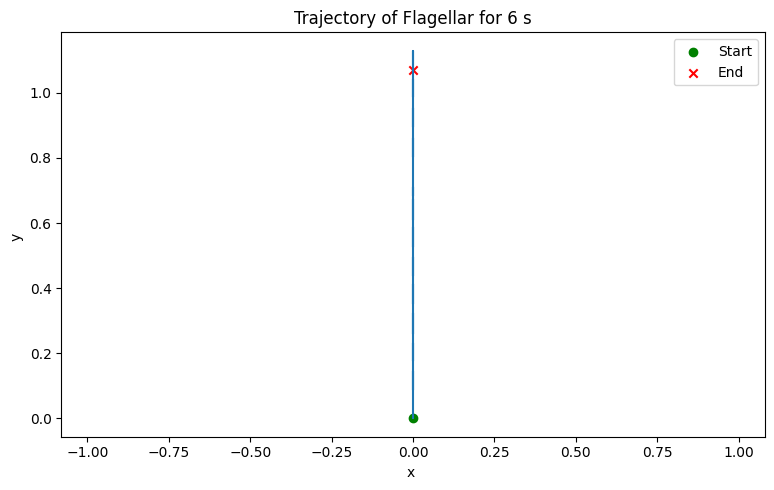

In [123]:
sol = scipy.integrate.solve_ivp(system_dynamics, [0,6], [0,0,np.pi/2], t_eval=np.linspace(0, 6, 100))


plt.figure(figsize=(8,5))
plt.plot(sol.y[0], sol.y[1])
plt.scatter(sol.y[0, 0], sol.y[1, 0], color='green', marker='o', label='Start')
plt.scatter(sol.y[0, -1], sol.y[1, -1], color='red', marker='x', label='End')
plt.axis('equal')
plt.xlabel('x ')
plt.ylabel('y ')
plt.title('Trajectory of Flagellar for 6 s')
plt.legend()
plt.tight_layout()
plt.show()

In [124]:
#part 2 
def gait_generator(t, coeff):
    N = int(len(coeff) / 4)
    
    a = coeff[0*N : 1*N]
    b = coeff[1*N : 2*N]
    c = coeff[2*N : 3*N]
    d = coeff[3*N : 4*N]
    w = 2*np.pi
    

    alpha1 = 0 
    alpha2 = 0
    alpha1_dot = 0 
    alpha2_dot = 0 

    for i in range(N):
        n = i+1
        alpha1 = alpha1 + a[i]*np.cos(n*w*t) + b[i]*np.sin(n*w*t)
        alpha2 = alpha2 + c[i]*np.cos(n*w*t) + d[i]*np.sin(n*w*t)

        alpha1_dot = alpha1_dot - a[i]*n*w*np.sin(n*w*t) + b[i]*n*w*np.cos(n*w*t)
        alpha2_dot = alpha2_dot - c[i]*n*w*np.sin(n*w*t) + d[i]*n*w*np.cos(n*w*t)

    return alpha1, alpha2, alpha1_dot, alpha2_dot

In [125]:
#part 3 
#params = [k,l,d]
def gait_cycle(coefficients, params, T = 2*np.pi):
    
    def dynamics(t,state):
        x,y,theta = state
        a1, a2, a1_dot, a2_dot = gait_generator(t, coefficients)
        Z = recon_matrix_num(theta, a1, a2, params[0], params[1], params[2])
        g_dot = Z @ np.array([[a1_dot], [a2_dot]])
        return [g_dot[0,0], g_dot[1,0], g_dot[2,0]]
    
    t_eval = np.linspace(0,T,100)
    sol = scipy.integrate.solve_ivp(dynamics, [0,T], [0,0,np.pi/2], t_eval = t_eval)
    time = sol.t 
    x_sol, y_sol, theta_sol = sol.y 

    res = [gait_generator(t_i, coefficients) for t_i in time]
    alpha_1_sol = [r[0] for r in res]
    alpha_2_sol = [r[1] for r in res]
    alpha_1_dot_sol = [r[2] for r in res]
    alpha_2_dot_sol = [r[3] for r in res]

    vels = [dynamics(t_i, [xs, ys, ts]) for t_i, xs, ys, ts in zip(time, x_sol, y_sol, theta_sol)]
    x_dot_sol = [v[0] for v in vels]
    y_dot_sol = [v[1] for v in vels]
    theta_dot_sol = [v[2] for v in vels]
        

    return time, x_sol, y_sol, theta_sol, alpha_1_sol, alpha_2_sol, \
           x_dot_sol, y_dot_sol, theta_dot_sol, alpha_1_dot_sol, alpha_2_dot_sol


def distance_y(coefficients, params):
    
    time, x_sol, y_sol, theta_sol, alpha_1_sol, alpha_2_sol, \
    x_dot_sol, y_dot_sol, theta_dot_sol, alpha_1_dot_sol, alpha_2_dot_sol = gait_cycle(coefficients, params, T=2*np.pi)
    
    distance = -(y_sol[-1] - y_sol[0])
    #### Make this negative so we force this to find the largest positive swimming direction
    
    return distance

def cost_of_transport(coefficients, params):
    time, x, y, th, a1, a2, x_d, y_d, th_d, a1_d, a2_d = gait_cycle(coefficients, params, T=2*np.pi)
    work = 0 

    for i in range(len(time)-1):
        a22_val = A22_func(th[i], a1[i], a2[i], params[0], params[1], params[2])
        alpha_dot = np.array([[a1_d[i]], [a2_d[i]]])
        power = alpha_dot.T @ a22_val @ alpha_dot
        dt = time[i+1] - time[i]
        work = work + power[0,0]*dt
    
    displacement = y[-1] - y[0]
    
    
    return float(work/displacement)

        

In [126]:
guess = [0,0.5,0.5,0]
params = [1.0, 2.0, 1.0]
dist_opt = scipy.optimize.minimize(distance_y,guess,args=(params,))
print("Optimal coefficients found:", dist_opt.x)
print("Maximized distance:", -dist_opt.fun)

Optimal coefficients found: [4.88048671e-08 5.00000000e-01 4.99999997e-01 1.42718806e-08]
Maximized distance: 0.6880712786179414


In [127]:

cot_opt = scipy.optimize.minimize(cost_of_transport, dist_opt.x, args=(params,)) 
print(f"Minimum Cost of Transport found: {cot_opt.fun:.4f}")

Minimum Cost of Transport found: 306.3065


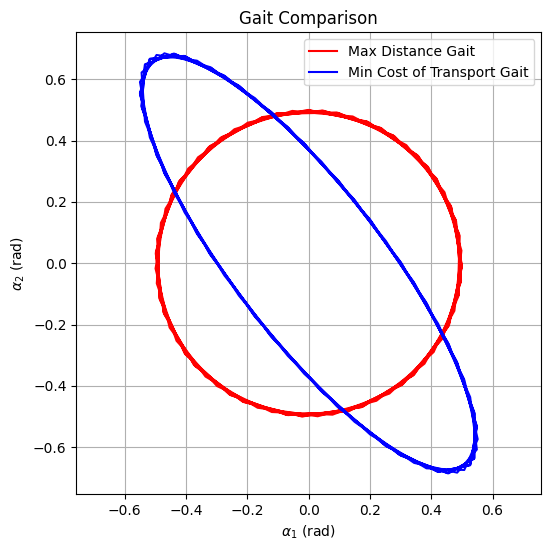

In [128]:
t_plot = np.linspace(0, 2*np.pi, 100)

a1_dist, a2_dist, _, _ = gait_generator(t_plot, dist_opt.x)

a1_cot, a2_cot, _, _ = gait_generator(t_plot, cot_opt.x)

plt.figure(figsize=(6,6))
plt.plot(a1_dist, a2_dist, 'r-', label='Max Distance Gait')
plt.plot(a1_cot, a2_cot, 'b-', label='Min Cost of Transport Gait')
plt.xlabel(r'$\alpha_1$ (rad)')
plt.ylabel(r'$\alpha_2$ (rad)')
plt.title('Gait Comparison')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()